# WeatherPy

---

## Starter Code to Generate Random Geographic Coordinates and a List of Cities

In [ ]:
# Dependencies and Setup
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import requests
import time
from scipy.stats import linregress

# Impor the OpenWeatherMap API key
from api_keys import weather_api_key

# Import citipy to determine the cities based on latitude and longitude
from citipy import citipy

### Generate the Cities List by Using the `citipy` Library

In [3]:
# Empty list for holding the latitude and longitude combinations
lat_lngs = []

# Empty list for holding the cities names
cities = []

# Range of latitudes and longitudes
lat_range = (-90, 90)
lng_range = (-180, 180)

# Create a set of random lat and lng combinations
lats = np.random.uniform(lat_range[0], lat_range[1], size=1500)
lngs = np.random.uniform(lng_range[0], lng_range[1], size=1500)
lat_lngs = zip(lats, lngs)

# Identify nearest city for each lat, lng combination
for lat_lng in lat_lngs:
    city = citipy.nearest_city(lat_lng[0], lat_lng[1]).city_name
    
    # If the city is unique, then add it to a our cities list
    if city not in cities:
        cities.append(city)

# Print the city count to confirm sufficient count
print(f"Number of cities in the list: {len(cities)}")

Number of cities in the list: 612


---

## Requirement 1: Create Plots to Showcase the Relationship Between Weather Variables and Latitude

### Use the OpenWeatherMap API to retrieve weather data from the cities list generated in the started code

In [4]:
# Set the API base URL
url = "http://api.openweathermap.org/data/2.5/weather?"

# Define an empty list to fetch the weather data for each city
city_data = []

# Print to logger
print("Beginning Data Retrieval     ")
print("-----------------------------")

# Create counters
record_count = 1
set_count = 1

# Loop through all the cities in our list to fetch weather data
for i, city in enumerate(cities):
        
    # Group cities in sets of 50 for logging purposes
    if (i % 50 == 0 and i >= 50):
        set_count += 1
        record_count = 0

    # Create endpoint URL with each city
    city_url = f"https://api.openweathermap.org/data/2.5/weather?q={city}&appid={weather_api_key}"
    
    # Log the url, record, and set numbers
    print("Processing Record %s of Set %s | %s" % (record_count, set_count, city))
    # Add 1 to the record count
    record_count += 1

    # Run an API request for each of the cities
    try:
        # Parse the JSON and retrieve data
        city_weather = requests.get(city_url).json()

        # Parse out latitude, longitude, max temp, humidity, cloudiness, wind speed, country, and date
        city_lat = city_weather['coord']['lat']
        city_lng = city_weather['coord']['lon']
        city_max_temp = city_weather['main']['temp_max']
        city_humidity = city_weather['main']['humidity']
        city_clouds = city_weather['clouds']['all']
        city_wind = city_weather['wind']['speed']
        city_country = city_weather['sys']['country']
        city_date = city_weather['dt']

        # Append the City information into city_data list
        city_data.append({"City": city, 
                          "Lat": city_lat, 
                          "Lng": city_lng, 
                          "Max Temp": city_max_temp,
                          "Humidity": city_humidity,
                          "Cloudiness": city_clouds,
                          "Wind Speed": city_wind,
                          "Country": city_country,
                          "Date": city_date})

    # If an error is experienced, skip the city
    except:
        print("City not found. Skipping...")
        pass
              
# Indicate that Data Loading is complete 
print("-----------------------------")
print("Data Retrieval Complete      ")
print("-----------------------------")

Beginning Data Retrieval     
-----------------------------
Processing Record 1 of Set 1 | lebu
Processing Record 2 of Set 1 | hawaiian paradise park
Processing Record 3 of Set 1 | atafu village
Processing Record 4 of Set 1 | albany
Processing Record 5 of Set 1 | fortuna
Processing Record 6 of Set 1 | mount pearl
Processing Record 7 of Set 1 | margaret river
Processing Record 8 of Set 1 | mahgawan
Processing Record 9 of Set 1 | waitangi
Processing Record 10 of Set 1 | udachny
Processing Record 11 of Set 1 | kudahuvadhoo
Processing Record 12 of Set 1 | laguna
Processing Record 13 of Set 1 | majenang
Processing Record 14 of Set 1 | sinabang
Processing Record 15 of Set 1 | blackmans bay
Processing Record 16 of Set 1 | idri
Processing Record 17 of Set 1 | bethel
Processing Record 18 of Set 1 | bilibino
Processing Record 19 of Set 1 | enewetak
Processing Record 20 of Set 1 | ketchikan
Processing Record 21 of Set 1 | college
Processing Record 22 of Set 1 | cairns city
City not found. Skippin

In [7]:
# Convert the cities weather data into a Pandas DataFrame
city_data_df = pd.DataFrame(city_data)

# Show Record Count
city_data_df.count()

City          590
Lat           590
Lng           590
Max Temp      590
Humidity      590
Cloudiness    590
Wind Speed    590
Country       590
Date          590
dtype: int64

In [8]:
# Display sample data
city_data_df.head()

,City,Lat,Lng,Max Temp,Humidity,Cloudiness,Wind Speed,Country,Date
0,lebu,-37.6167,-73.6500,282.26,60,22,4.48,CL,1724102160
1,hawaiian paradise park,19.5933,-154.9731,301.89,75,25,1.34,US,1724102160
2,atafu village,-8.5421,-172.5159,301.26,77,42,9.91,TK,1724102161
3,albany,42.6001,-73.9662,295.38,94,97,0.89,US,1724102161
4,fortuna,40.5982,-124.1573,294.66,60,0,4.63,US,1724102161


In [11]:
# Export the City_Data into a csv
city_data_df.to_csv("output_data/cities.csv", index_label="City_ID")

In [13]:
# Read saved data
city_data_df = pd.read_csv("output_data/cities.csv", index_col="City_ID")

# Display sample data
city_data_df.head()

,City,Lat,Lng,Max Temp,Humidity,Cloudiness,Wind Speed,Country,Date
City_ID,,,,,,,,,
0,lebu,-37.6167,-73.6500,282.26,60,22,4.48,CL,1724102160
1,hawaiian paradise park,19.5933,-154.9731,301.89,75,25,1.34,US,1724102160
2,atafu village,-8.5421,-172.5159,301.26,77,42,9.91,TK,1724102161
3,albany,42.6001,-73.9662,295.38,94,97,0.89,US,1724102161
4,fortuna,40.5982,-124.1573,294.66,60,0,4.63,US,1724102161


### Create the Scatter Plots Requested

#### Latitude Vs. Temperature

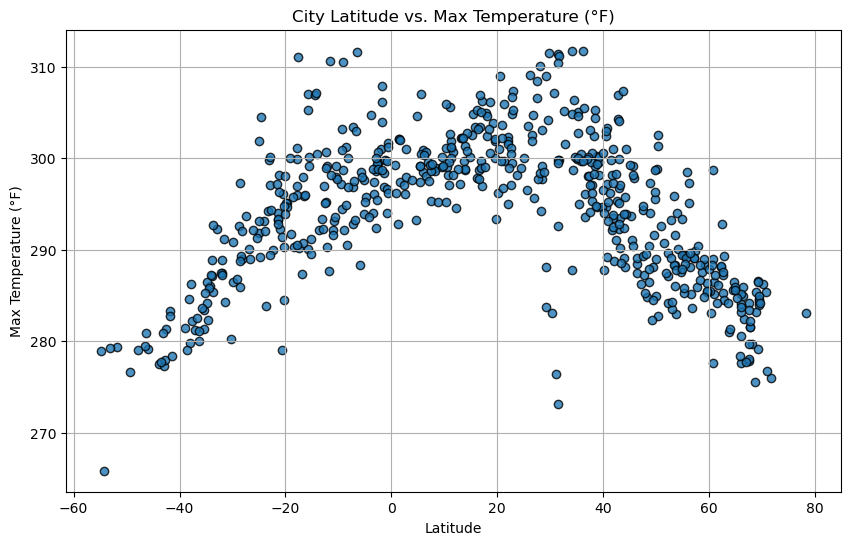

In [15]:
# Build scatter plot for latitude vs. temperature
plt.figure(figsize=(10, 6))

# Scatter plot: Latitude vs. Max Temperature
plt.scatter(city_data_df["Lat"], city_data_df["Max Temp"], 
            edgecolor="black", linewidths=1, marker="o", 
            alpha=0.8, label="Cities")

# Incorporate other graph properties
plt.title("City Latitude vs. Max Temperature (°F)")
plt.xlabel("Latitude")
plt.ylabel("Max Temperature (°F)")
plt.grid(True)

# Save the figure
plt.savefig("output_data/Fig1.png")

# Show plot
plt.show()


#### Latitude Vs. Humidity

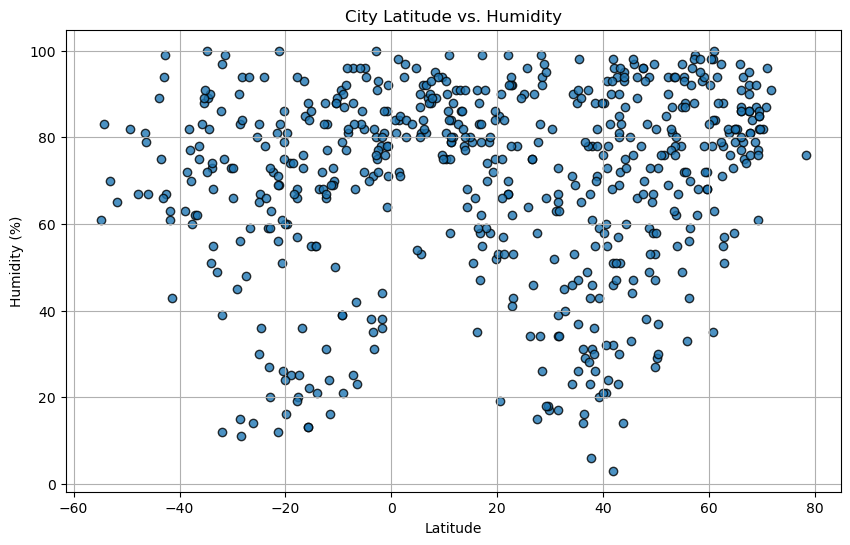

In [16]:
# Build the scatter plots for latitude vs. humidity

plt.figure(figsize=(10, 6))

# Scatter plot: Latitude vs. Max Temperature
plt.scatter(city_data_df["Lat"], city_data_df["Humidity"], 
            edgecolor="black", linewidths=1, marker="o", 
            alpha=0.8, label="Cities")

# Incorporate other graph properties
plt.title("City Latitude vs. Humidity")
plt.xlabel("Latitude")
plt.ylabel("Humidity (%)")
plt.grid(True)

# Save the figure
plt.savefig("output_data/Fig2.png")

# Show plot
plt.show()


#### Latitude Vs. Cloudiness

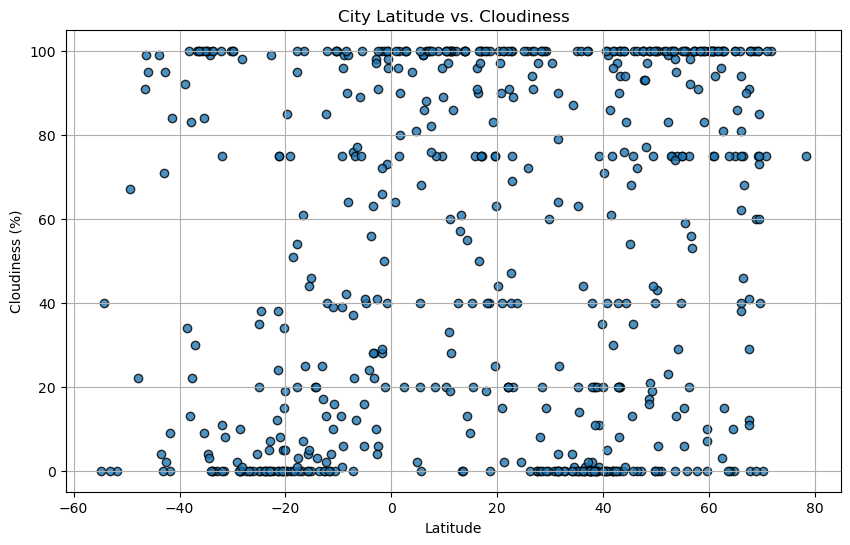

In [17]:
# Build the scatter plots for latitude vs. cloudiness

plt.figure(figsize=(10, 6))

# Scatter plot: Latitude vs. Max Temperature
plt.scatter(city_data_df["Lat"], city_data_df["Cloudiness"], 
            edgecolor="black", linewidths=1, marker="o", 
            alpha=0.8, label="Cities")

# Incorporate other graph properties
plt.title("City Latitude vs. Cloudiness")
plt.xlabel("Latitude")
plt.ylabel("Cloudiness (%)")
plt.grid(True)

# Save the figure
plt.savefig("output_data/Fig3.png")

# Show plot
plt.show()

#### Latitude vs. Wind Speed Plot

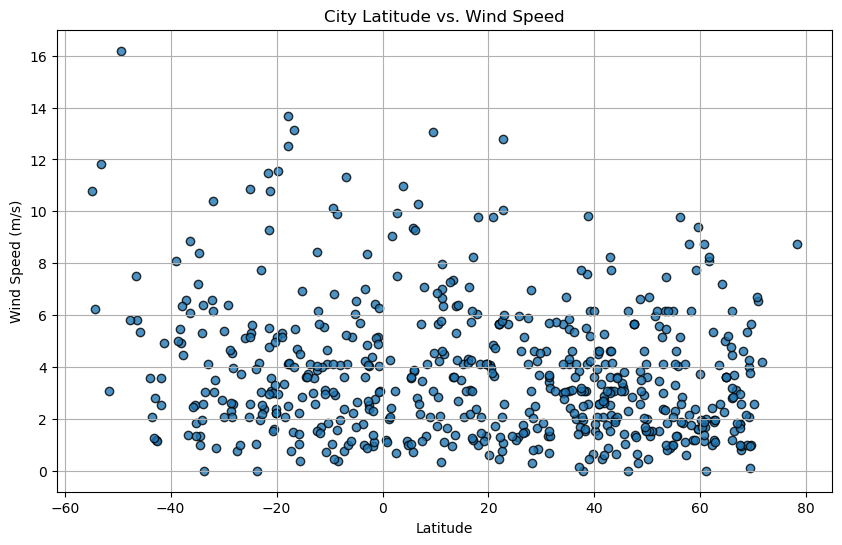

In [18]:
# Build the scatter plots for latitude vs. wind speed
plt.figure(figsize=(10, 6))

# Scatter plot: Latitude vs. Max Temperature
plt.scatter(city_data_df["Lat"], city_data_df["Wind Speed"], 
            edgecolor="black", linewidths=1, marker="o", 
            alpha=0.8, label="Cities")

# Incorporate other graph properties
plt.title("City Latitude vs. Wind Speed")
plt.xlabel("Latitude")
plt.ylabel("Wind Speed (m/s)")
plt.grid(True)

# Save the figure
plt.savefig("output_data/Fig4.png")

# Show plot
plt.show()

---

## Requirement 2: Compute Linear Regression for Each Relationship


In [26]:
def plot_linear_regression(x_values, y_values, title, xlabel, ylabel, text_coords):
    """
    Plots a scatter plot with a linear regression line, shows the regression equation on the plot,
    and returns the R² value for printing.
    
    Parameters:
    x_values (array-like): The data for the x-axis (independent variable).
    y_values (array-like): The data for the y-axis (dependent variable).
    title (str): The title of the plot.
    xlabel (str): The label for the x-axis.
    ylabel (str): The label for the y-axis.
    text_coords (tuple): The x and y coordinates for the regression equation text on the plot.
    
    Returns:
    float: The R² value of the linear regression.
    """
    # Perform linear regression
    (slope, intercept, rvalue, pvalue, stderr) = linregress(x_values, y_values)
    
    # Calculate the regression line's y-values
    regress_values = x_values * slope + intercept
    
    # Create the scatter plot
    plt.scatter(x_values, y_values, edgecolors="black", linewidths=1, marker="o", alpha=0.8)
    
    # Plot the regression line
    plt.plot(x_values, regress_values, "r-")
    
    # Annotate the equation on the plot
    plt.annotate(f"y = {slope:.2f}x + {intercept:.2f}", text_coords, fontsize=12, color="red")
    
    # Set title and labels
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    
    # Show grid
    plt.grid(True)

    # Show the plot
    plt.show()
    
    # Return the R² value for printing
    return rvalue**2


In [20]:
# Create a DataFrame with the Northern Hemisphere data (Latitude >= 0)
northern_hemi_df = city_data_df[city_data_df['Lat'] >= 0]

# Display sample data
northern_hemi_df.head()

,City,Lat,Lng,Max Temp,Humidity,Cloudiness,Wind Speed,Country,Date
City_ID,,,,,,,,,
1,hawaiian paradise park,19.5933,-154.9731,301.89,75,25,1.34,US,1724102160
3,albany,42.6001,-73.9662,295.38,94,97,0.89,US,1724102161
4,fortuna,40.5982,-124.1573,294.66,60,0,4.63,US,1724102161
5,mount pearl,47.5166,-52.7813,294.34,96,100,5.66,CA,1724102162
7,mahgawan,26.5000,78.6042,302.58,75,100,1.76,IN,1724102162


In [21]:
# Create a DataFrame with the Southern Hemisphere data (Latitude < 0)
southern_hemi_df = city_data_df[city_data_df['Lat'] < 0]

# Display sample data
southern_hemi_df.head()

,City,Lat,Lng,Max Temp,Humidity,Cloudiness,Wind Speed,Country,Date
City_ID,,,,,,,,,
0,lebu,-37.6167,-73.6500,282.26,60,22,4.48,CL,1724102160
2,atafu village,-8.5421,-172.5159,301.26,77,42,9.91,TK,1724102161
6,margaret river,-33.9500,115.0667,287.17,73,100,6.39,AU,1724102162
8,waitangi,-43.9535,-176.5597,277.49,89,99,3.58,NZ,1724102163
12,majenang,-7.2975,108.7642,292.79,96,76,0.77,ID,1724102164


###  Temperature vs. Latitude Linear Regression Plot

The R² value is: 0.51


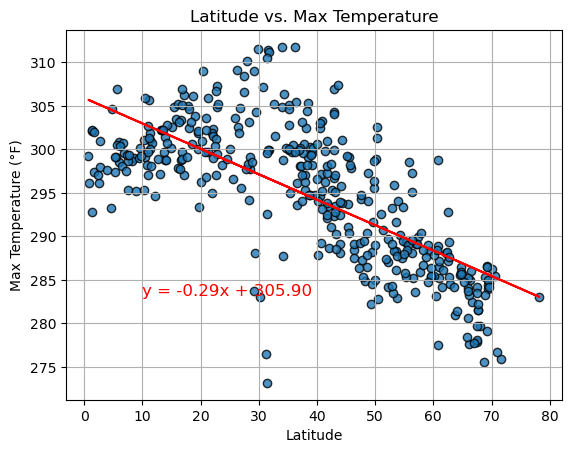

In [28]:
# Perform linear regression on Latitude vs. Max Temperature for the Northern Hemisphere
x_values = northern_hemi_df["Lat"]
y_values = northern_hemi_df["Max Temp"]

# Print the R² value
print(f"The R² value is: {r_squared:.2f}")

# Plot the linear regression and get the R² value
r_squared = plot_linear_regression(x_values, y_values,
                                   "Latitude vs. Max Temperature",
                                   "Latitude", "Max Temperature (°F)",
                                   text_coords=(10, y_values.min() + 10))

The R² value is: 0.62


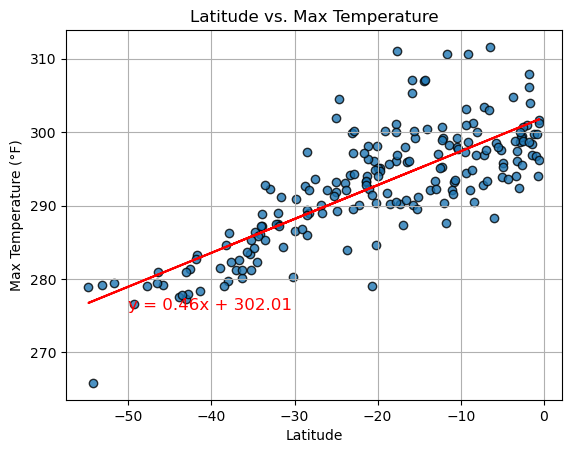

In [30]:
# Perform linear regression on Latitude vs. Max Temperature for the Southern Hemisphere
x_values = southern_hemi_df["Lat"]
y_values = southern_hemi_df["Max Temp"]

# Print the R² value
print(f"The R² value is: {r_squared:.2f}")

# Plot the linear regression and get the R² value
r_squared = plot_linear_regression(x_values, y_values,
                                   "Latitude vs. Max Temperature",
                                   "Latitude", "Max Temperature (°F)",
                                   text_coords=(-50, y_values.min() + 10))

**Discussion about the linear relationship:** Across both hemispheres, there is an inverse relationship between latitude and temperature. As latitude increases (moving away from the equator in either direction), the maximum temperature generally decreases.

### Humidity vs. Latitude Linear Regression Plot

The R² value is: 0.62


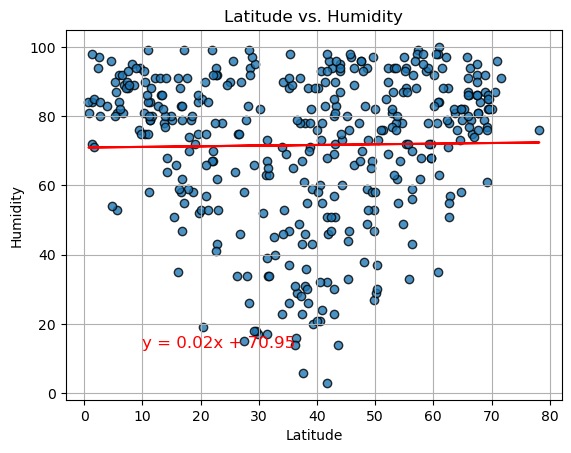

In [31]:
# Perform linear regression on Humidity vs Latitude for the Northern Hemisphere
x_values = northern_hemi_df["Lat"]
y_values = northern_hemi_df["Humidity"]

# Print the R² value
print(f"The R² value is: {r_squared:.2f}")

# Plot the linear regression and get the R² value
r_squared = plot_linear_regression(x_values, y_values,
                                   "Latitude vs. Humidity",
                                   "Latitude", "Humidity",
                                   text_coords=(10, y_values.min() + 10))

The R² value is: 0.00


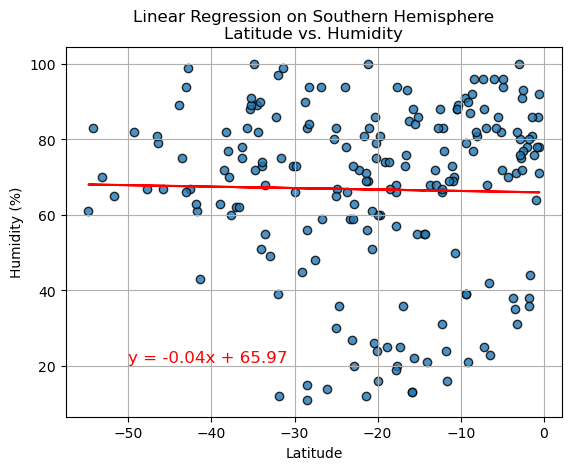

In [32]:
# Perform linear regression on Latitude vs. Humidity for the Southern Hemisphere
x_values = southern_hemi_df["Lat"]
y_values = southern_hemi_df["Humidity"]

# Print the R² value
print(f"The R² value is: {r_squared:.2f}")

# Plot the linear regression and get the R² value
r_squared = plot_linear_regression(x_values, y_values,
                                   "Linear Regression on Southern Hemisphere\nLatitude vs. Humidity",
                                   "Latitude", "Humidity (%)",
                                   text_coords=(-50, y_values.min() + 10))

**Discussion about the linear relationship:** When analyzing both hemispheres, the overall relationship between latitude and humidity may appear weak or complex, as local climate factors significantly influence humidity beyond just latitude. While there is some relationship between latitude and humidity, it is not as strong or direct as with temperature. The R² value likely reflects this complexity, indicating that latitude alone does not fully explain variations in humidity.

### Cloudiness vs. Latitude Linear Regression Plot

The R² value is: 0.00


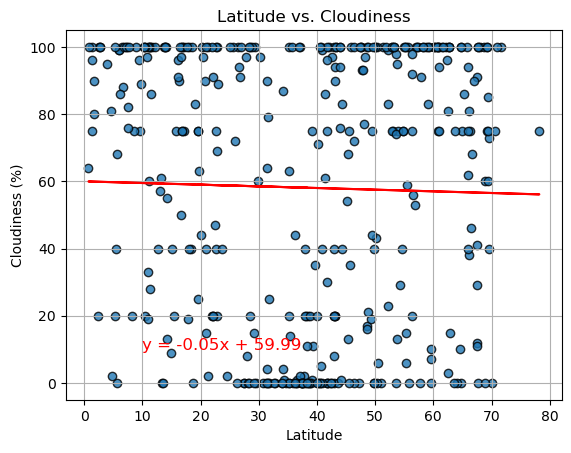

In [34]:
# Perform linear regression on Latitude vs. Cloudiness for the Northern Hemisphere
x_values = northern_hemi_df["Lat"]
y_values = northern_hemi_df["Cloudiness"]

# Print the R² value
print(f"The R² value is: {r_squared:.2f}")

# Plot the linear regression and get the R² value
r_squared = plot_linear_regression(x_values, y_values,
                                   "Latitude vs. Cloudiness",
                                   "Latitude", "Cloudiness (%)",
                                   text_coords=(10, y_values.min() + 10))

The R² value is: 0.00


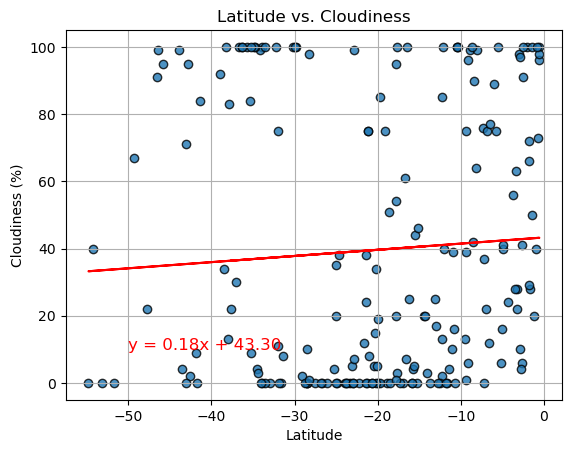

In [35]:
# Perform linear regression on Latitude vs. Cloudiness for the Southern Hemisphere
x_values = southern_hemi_df["Lat"]
y_values = southern_hemi_df["Cloudiness"]

# Print the R² value
print(f"The R² value is: {r_squared:.2f}")

# Plot the linear regression and get the R² value
r_squared = plot_linear_regression(x_values, y_values,
                                   "Latitude vs. Cloudiness",
                                   "Latitude", "Cloudiness (%)",
                                   text_coords=(-50, y_values.min() + 10))

**Discussion about the linear relationship:** The relationship between cloudiness and latitude is complex and not strongly linear in either hemisphere. While latitude plays a role, cloudiness is heavily influenced by local and regional factors, resulting in a weak correlation as reflected by the R² values in both hemispheres.

### Wind Speed vs. Latitude Linear Regression Plot

The R² value is: 0.00


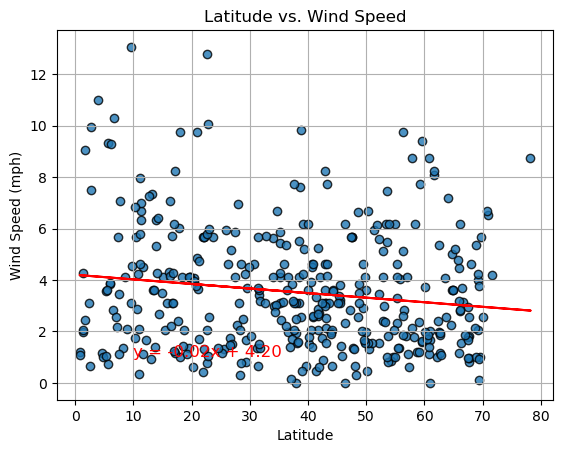

In [40]:
# Perform linear regression on Latitude vs. Wind Speed for the Northern Hemisphere
x_values_north = northern_hemi_df["Lat"]
y_values_north = northern_hemi_df["Wind Speed"]

# Print the R² value for the Northern Hemisphere
print(f"The R² value is: {r_squared:.2f}")

# Plot the linear regression and get the R² value for the Northern Hemisphere
r_squared_north = plot_linear_regression(x_values_north, y_values_north,
                                         "Latitude vs. Wind Speed",
                                         "Latitude", "Wind Speed (mph)",
                                         text_coords=(10, y_values_north.min() + 1))

The R² value is: 0.00


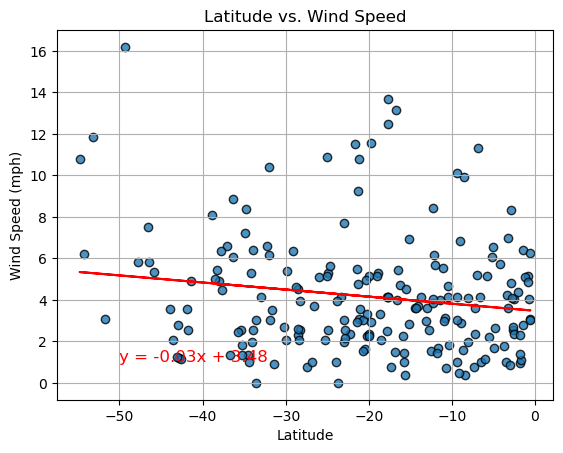

In [41]:
# Perform linear regression on Latitude vs. Wind Speed for the Southern Hemisphere
x_values_south = southern_hemi_df["Lat"]
y_values_south = southern_hemi_df["Wind Speed"]

# Print the R² value for the Southern Hemisphere
print(f"The R² value is: {r_squared:.2f}")

# Plot the linear regression and get the R² value for the Southern Hemisphere
r_squared_south = plot_linear_regression(x_values_south, y_values_south,
                                         "Latitude vs. Wind Speed",
                                         "Latitude", "Wind Speed (mph)",
                                         text_coords=(-50, y_values_south.min() + 1))

**Discussion about the linear relationship:** The relationship between wind speed and latitude in both hemispheres is complex and only weakly linear. The low R² values suggest that latitude is not a sufficient predictor of wind speed on its own, as wind speed is influenced by a range of dynamic atmospheric and geographic factors.